In [1]:
import os

qiime_env = "/homes/kbalzer/miniconda3/envs/qiime2-amplicon-2026.1"

os.environ["R_HOME"] = f"{qiime_env}/lib/R"

os.environ["PATH"] = (
    f"{qiime_env}/bin:" + os.environ["PATH"]
)

os.environ["CONDA_PREFIX"] = qiime_env

print("R_HOME =", os.environ["R_HOME"])

R_HOME = /homes/kbalzer/miniconda3/envs/qiime2-amplicon-2026.1/lib/R


In [2]:
import warnings

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="seaborn",
)

In [4]:
import ancombc2_heatmaps as ah


In [5]:
print(ah.__version__)

2.0.0


In [3]:
import ancombc2_heatmaps as ah

timepoints = [
    "baseline1", "baseline2", "baseline3",
    "day1", "day3", "day7", "day14",
]

timepoint_map = {
    "baseline_1": "baseline1",
    "baseline_2": "baseline2",
    "baseline_3": "baseline3",
    "day_1_post": "day1",
    "day_3_post": "day3",
    "day_7_post": "day7",
    "day_14_post": "day14",
}

config = ah.ANCOMConfig(
    metadata_path="/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/metadata_microbian2_26.02.2026.txt",
    output_dir="/tmp/ancombc2_package_same_heatmap",

    table_base="/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint",
    ancom_base="/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/real_ANCOMB_BC2",

    sample_col="sample_name",
    timepoint_col="time_point",
    group_col="description_of_treatment",
    subject_col=None,

    timepoints=timepoints,
    timepoint_map=timepoint_map,

    allowed_values={
        "description_of_treatment": ["sham", "irradiated"],
    },

    table_template="table_{timepoint}_genus_ANCOM.qza",
    ancom_template="{timepoint}_treat_ANCOMB_exported",

    variable_name="description_of_treatment",

    split_after_timepoint="baseline3",

)

workflow = ah.ANCOMWorkflow(config)

subset = ah.Subset(
    label="",
    title="All samples",
    filters={},
)

In [4]:
workflow.check(subset)

,timepoint,table_path,table_exists,ancom_path,ancom_exists
0,baseline1,/vol/jlab/MicrobiomeAnalyses/Projects/JansenVa...,True,/vol/jlab/MicrobiomeAnalyses/Projects/JansenVa...,True
1,baseline2,/vol/jlab/MicrobiomeAnalyses/Projects/JansenVa...,True,/vol/jlab/MicrobiomeAnalyses/Projects/JansenVa...,True
2,baseline3,/vol/jlab/MicrobiomeAnalyses/Projects/JansenVa...,True,/vol/jlab/MicrobiomeAnalyses/Projects/JansenVa...,True
3,day1,/vol/jlab/MicrobiomeAnalyses/Projects/JansenVa...,True,/vol/jlab/MicrobiomeAnalyses/Projects/JansenVa...,True
4,day3,/vol/jlab/MicrobiomeAnalyses/Projects/JansenVa...,True,/vol/jlab/MicrobiomeAnalyses/Projects/JansenVa...,True
5,day7,/vol/jlab/MicrobiomeAnalyses/Projects/JansenVa...,True,/vol/jlab/MicrobiomeAnalyses/Projects/JansenVa...,True
6,day14,/vol/jlab/MicrobiomeAnalyses/Projects/JansenVa...,True,/vol/jlab/MicrobiomeAnalyses/Projects/JansenVa...,True


/homes/kbalzer/miniconda3/envs/qiime2-amplicon-2026.1/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


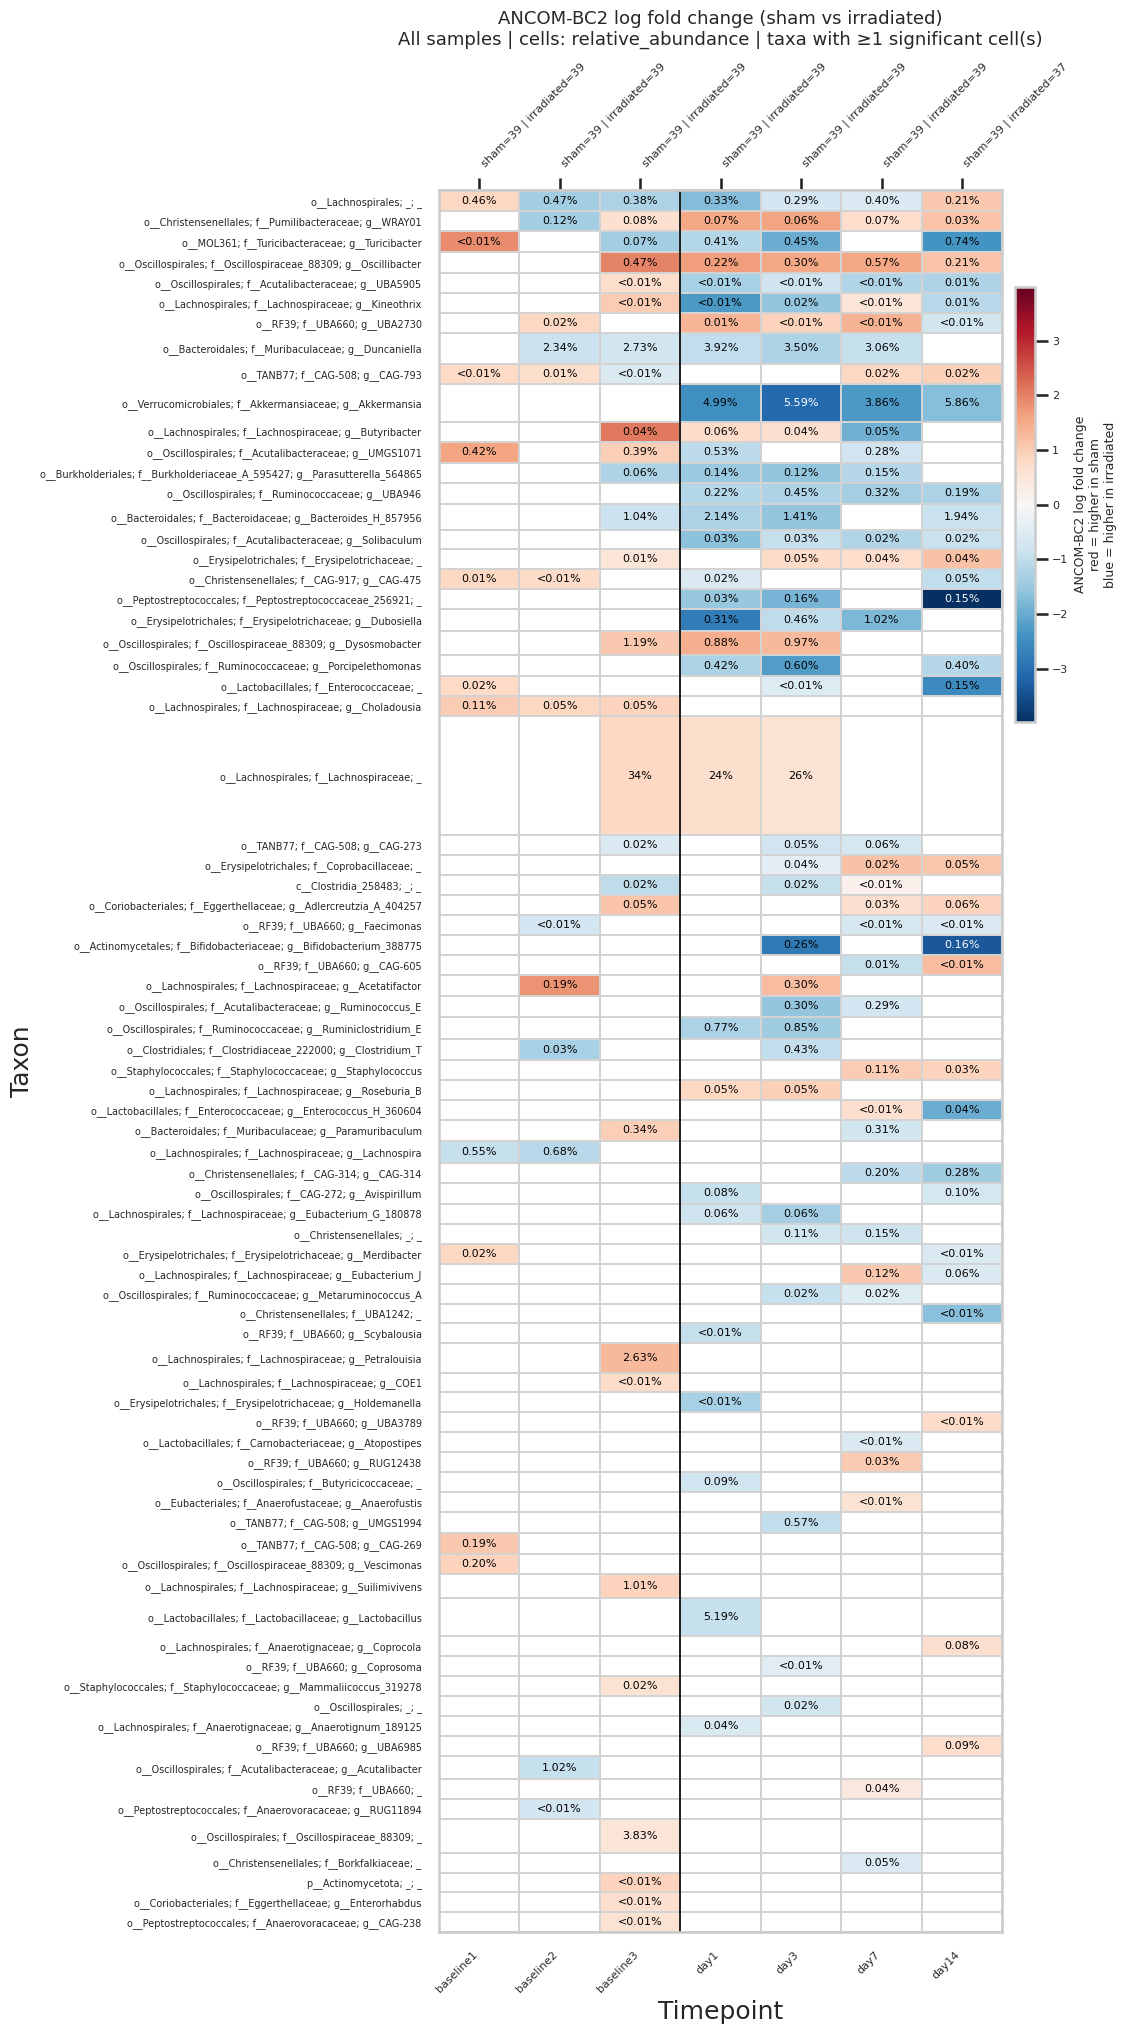

(<Figure size 1310x2419.27 with 2 Axes>,
 <Axes: title={'center': 'ANCOM-BC2 log fold change (sham vs irradiated)\nAll samples | cells: relative_abundance | taxa with ≥1 significant cell(s)'}, xlabel='Timepoint', ylabel='Taxon'>)

In [8]:
workflow.heatmap(
    subset,
    save_png=False,
    save_pdf=False,
    show=True,
)

/homes/kbalzer/miniconda3/envs/qiime2-amplicon-2026.1/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/homes/kbalzer/miniconda3/envs/qiime2-amplicon-2026.1/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


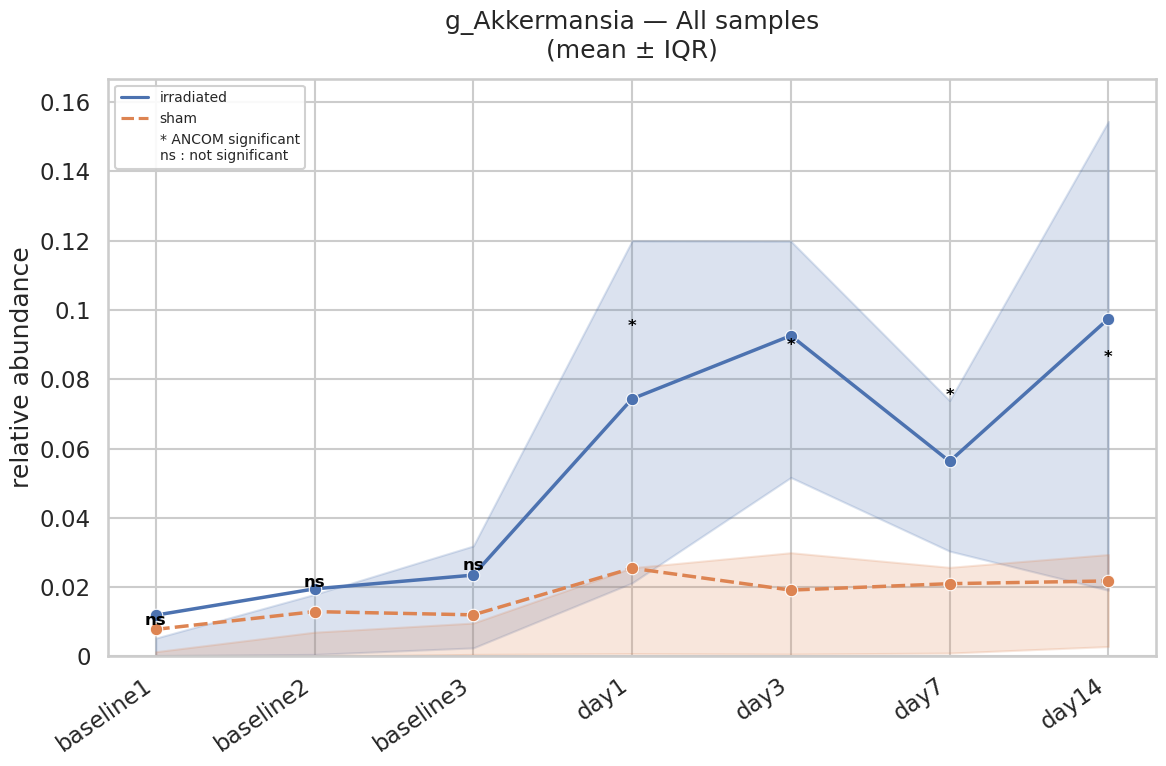

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'g_Akkermansia — All samples\n(mean ± IQR)'}, ylabel='relative abundance'>)

In [15]:
workflow.trajectory("g_Akkermansia", subset)


/homes/kbalzer/miniconda3/envs/qiime2-amplicon-2026.1/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/homes/kbalzer/miniconda3/envs/qiime2-amplicon-2026.1/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


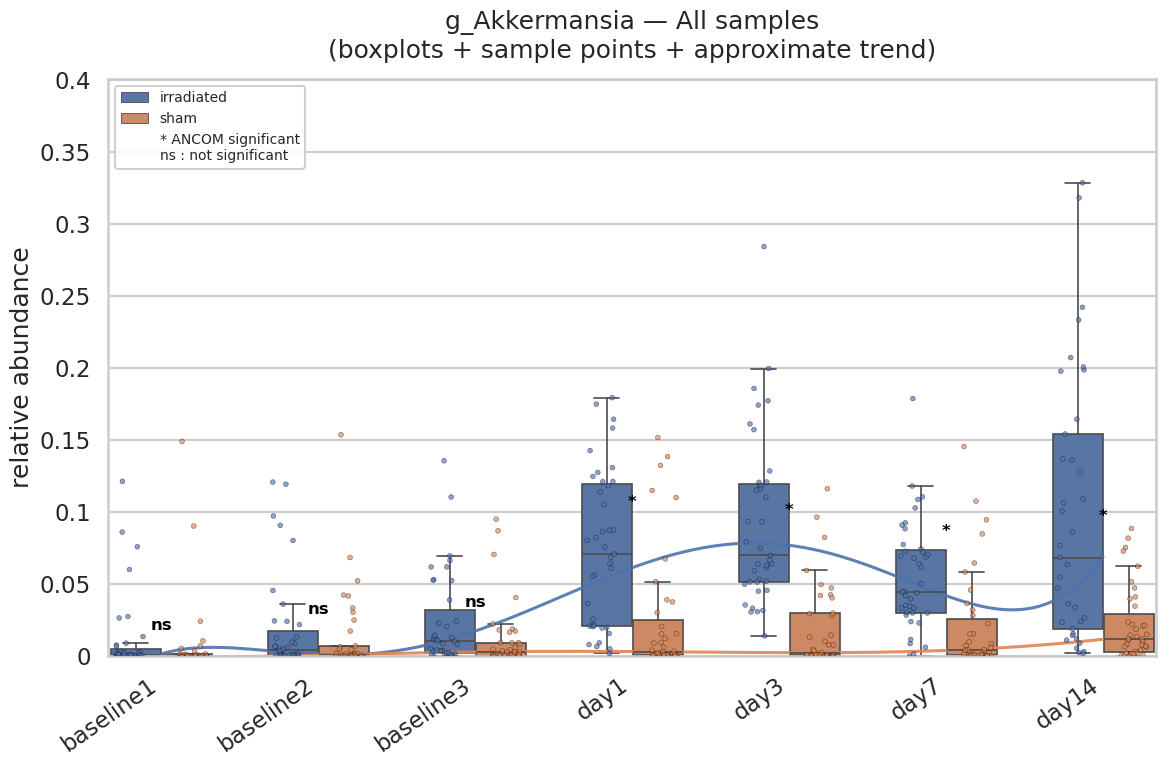

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'g_Akkermansia — All samples\n(boxplots + sample points + approximate trend)'}, ylabel='relative abundance'>)

In [18]:
workflow.boxplot(
    "g_Akkermansia",
    subset,
    show_trend=True,
    trend_order=5,
)

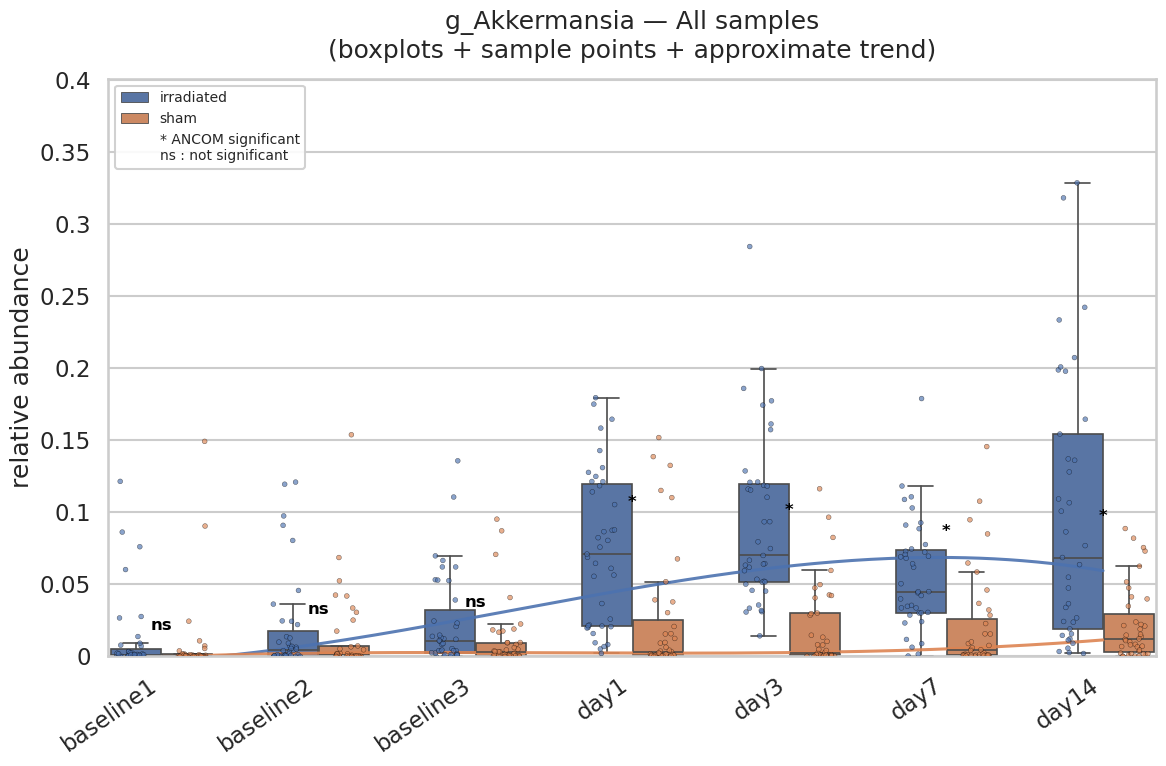

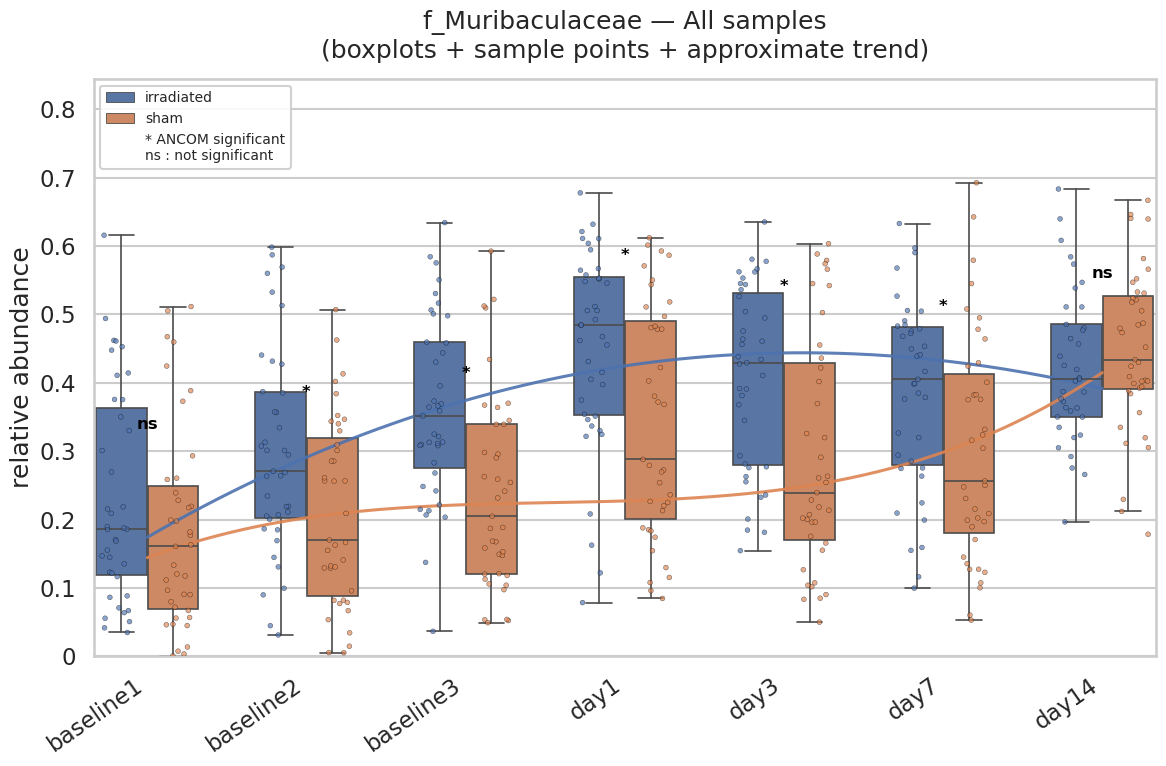

[NO BOXPLOT] No data: p_Verrucomicrobiota — All samples


[(<Figure size 1200x800 with 1 Axes>,
  <Axes: title={'center': 'g_Akkermansia — All samples\n(boxplots + sample points + approximate trend)'}, ylabel='relative abundance'>),
 (<Figure size 1200x800 with 1 Axes>,
  <Axes: title={'center': 'f_Muribaculaceae — All samples\n(boxplots + sample points + approximate trend)'}, ylabel='relative abundance'>),
 None]

In [10]:
workflow.boxplots(
    subset,
    show_trend=True,
    trend_order=3,
)